# Salary Prediction using Linear Regression

by Collins Kimotho

In [48]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [49]:
#Read data
df = pd.read_csv("salaries.csv")
df.head()

,years_of_experience,salary
0,5,3150
1,9,3787
2,4,2991
3,10,4551
4,8,3540


In [50]:
df.shape

(100, 2)

## Data Cleaning

In [51]:
#Get the number of duplicates
duplicates = df.duplicated().sum()
print(duplicates)

2


We have 2 duplicates in our dataset that we need to drop

In [52]:
#Drop duplicates
df.drop_duplicates(inplace=True)

In [55]:
#Check for nulls
df.isnull().sum()

years_of_experience    0
salary                 0
dtype: int64

In [ ]:
# Descriptive statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
years_of_experience,98.0,5.255102,2.617590,1.0,3.0,6.0,7.00,10.0
salary,98.0,3243.000000,542.917377,2237.0,2784.0,3263.0,3624.75,4708.0


## Linear regression model

In [22]:
#Data arrays
X = np.array(df['years_of_experience']).reshape(-1,1)
Y = np.array(df['salary'])

#Fitting the model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()
model.fit(X, Y)

# Make predictions
y_pred = model.predict(X)

In [18]:
#calculate mse and r2_score
mse = mean_squared_error(Y, y_pred)
r_squared = r2_score(Y, y_pred)


print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared: \t\t{r_squared:.2f}')

Mean Squared Error: 34796.96
R-squared: 		0.88


The model explains 88% of the variation in salary is due to years of experience. The remaining 12% could be due to other factors not in the model

In [16]:
m = model.coef_[0]
c = model.intercept_

In [21]:
print(f'Slope: \t\t{m:.2f}')
print(f'Intercept: \t{c:.2f}')

Slope: 		194.68
Intercept: 	2218.33


Linear regression equation

y = 194.68(x) + 2218.33

Linear equation: y = 194.68(years of experience) + 2218.22


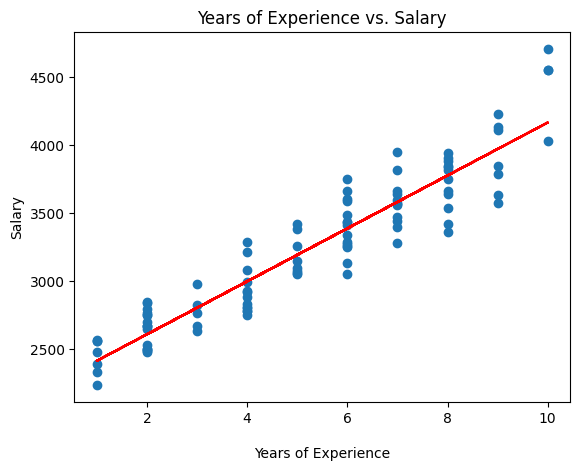

In [35]:
#Visualize
print('Linear equation: y = 194.68(years of experience) + 2218.22')
plt.scatter(x=df['years_of_experience'], y=df['salary'])
plt.plot(df['years_of_experience'], y_pred, color='red')

plt.ylabel('Salary')
plt.xlabel('\nYears of Experience')
plt.title('Years of Experience vs. Salary')
plt.show()